# Stochastic wealth process and inverse-gamma equilibrium

This notebook simulates the relative-wealth equation in `Paper/chapters/02_model.tex`, Eq. (16). Interpreting that equation in the Stratonovich sense gives

$$
dX = [J(1-X)-\sigma^2X]dt+\sqrt{2\sigma^2}\,X\circ dW_t.
$$

Converting to Itô adds $\sigma^2X$ to the drift, so the equivalent Itô SDE is

$$
dX=J(1-X)dt+\sqrt{2\sigma^2}\,X\,dW_t.
$$

Its Fokker–Planck equation is Eq. (17), with stationary inverse-gamma density (Eq. (18))

$$
p_\mathrm{st}(x)=\frac{\beta^\alpha}{\Gamma(\alpha)}x^{-\alpha-1}e^{-\beta/x},\qquad \alpha=1+\frac{J}{\sigma^2},\quad \beta=\frac{J}{\sigma^2},\quad x>0.
$$

The simulation uses a positivity-preserving split-step update: the mean-reversion substep and the geometric-noise substep are each integrated exactly. Their composition approximates the full SDE with finite-step splitting error. The model is a representative-agent mean-field diffusion: it gives $\mathbb{E}[X]=1$ when initialized at one, but independently simulated finite agents are not constrained to have sample mean exactly one.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from math import gamma
from scipy.special import gammaincc


In [2]:
# Parameters used in the paper's mean-field wealth model
J = 0.5
sigma = 0.5
n_agents = 30000
dt = 0.001
total_time = 40.0
n_steps = int(total_time / dt)

rng = np.random.default_rng(7)
print(f"Agents: {n_agents:,} | time step: {dt:g} | simulated time: {total_time:g}")


Agents: 30,000 | time step: 0.001 | simulated time: 40


In [8]:
# Positivity-preserving split-step update for the Ito SDE
# dX = J(1 - X)dt + sqrt(2 sigma^2) X dW.
# The mean-reversion and geometric-noise substeps are each integrated exactly.
X = np.ones(n_agents, dtype=float)
noise_amplitude = np.sqrt(2 * sigma**2)
sqrt_dt = np.sqrt(dt)
drift_decay = np.exp(-J * dt)
noise_log_drift = sigma**2 * dt

for _ in range(n_steps):
    drifted = 1 + (X - 1) * drift_decay
    lognormal_factor = np.exp(
        noise_amplitude * sqrt_dt * rng.standard_normal(n_agents) - noise_log_drift
    )
    X = drifted * lognormal_factor

if not np.all(np.isfinite(X)) or np.any(X <= 0):
    raise RuntimeError("The split-step simulation produced a non-positive or non-finite state.")

samples = X.copy()
print(f"Sampled {samples.size:,} agent wealth values at t={total_time:g}.")
print(f"Minimum sampled wealth: {samples.min():.4g}")
print(f"Maximum sampled wealth: {samples.max():.4g}")


Sampled 30,000 agent wealth values at t=40.
Minimum sampled wealth: 0.1368
Maximum sampled wealth: 22.42


In [9]:
# Stationary law and diagnostics derived from Eqs. (17)-(18)
alpha = 1 + J / sigma**2
beta = J / sigma**2


def inverse_gamma_pdf(x, alpha, beta):
    x = np.asarray(x, dtype=float)
    return beta**alpha / gamma(alpha) * x**(-alpha - 1) * np.exp(-beta / x)


def inverse_gamma_cdf(x, alpha, beta):
    x = np.asarray(x, dtype=float)
    cdf = np.zeros_like(x)
    positive = x > 0
    cdf[positive] = gammaincc(alpha, beta / x[positive])
    return cdf


theory_mean = beta / (alpha - 1)
theory_variance = beta**2 / ((alpha - 1)**2 * (alpha - 2)) if alpha > 2 else np.inf
sample_mean = samples.mean()
mean_standard_error = np.sqrt(theory_variance / n_agents)
ordered_samples = np.sort(samples)
empirical_cdf = np.arange(1, n_agents + 1) / n_agents
theory_cdf = inverse_gamma_cdf(ordered_samples, alpha, beta)
ks_distance = max(
    np.max(empirical_cdf - theory_cdf),
    np.max(theory_cdf - (empirical_cdf - 1 / n_agents)),
)

print(f"Inverse-gamma parameters: alpha={alpha:.3f}, beta={beta:.3f}")
print(f"Mean: simulated={sample_mean:.4f}, theoretical={theory_mean:.4f}")
print(f"Mean deviation in theoretical standard errors: {(sample_mean - theory_mean) / mean_standard_error:.2f}")
print(f"Variance: simulated={samples.var():.4f}, theoretical={theory_variance:.4f}")
print(f"Empirical-vs-theoretical CDF KS distance: {ks_distance:.4f}")


Inverse-gamma parameters: alpha=3.000, beta=2.000
Mean: simulated=0.9937, theoretical=1.0000
Mean deviation in theoretical standard errors: -1.10
Variance: simulated=0.8373, theoretical=1.0000
Empirical-vs-theoretical CDF KS distance: 0.0042


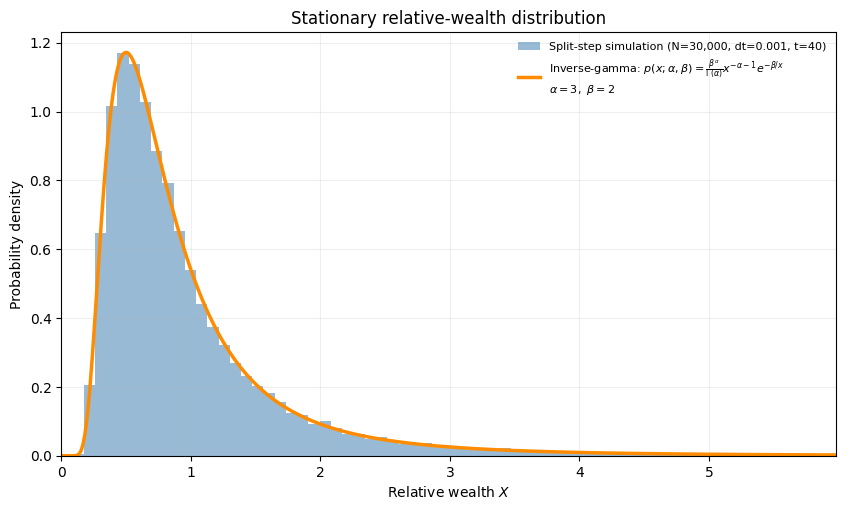

In [13]:
plot_max = float(np.quantile(samples, 0.995))
bin_edges = np.linspace(0, plot_max, 70)
bin_width = bin_edges[1] - bin_edges[0]
weights = np.full(samples.shape, 1 / (samples.size * bin_width))
x_grid = np.linspace(1e-4, plot_max, 600)
simulation_label = f"Split-step simulation (N={n_agents:,}, dt={dt:g}, t={total_time:g})"
theory_label = (
    rf"Inverse-gamma: $p(x;\alpha,\beta)=\frac{{\beta^\alpha}}{{\Gamma(\alpha)}}"
    rf"x^{{-\alpha-1}}e^{{-\beta/x}}$"
    "\n"
    rf"$\alpha={alpha:g},\ \beta={beta:g}$"
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(samples, bins=bin_edges, weights=weights, alpha=0.55, color="steelblue", label=simulation_label)
ax.plot(x_grid, inverse_gamma_pdf(x_grid, alpha, beta), color="darkorange", linewidth=2.5, label=theory_label)
ax.set(xlim=(0, plot_max), xlabel="Relative wealth $X$", ylabel="Probability density", title="Stationary relative-wealth distribution")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.2)
plt.show()


### Interpreting the comparison

For these parameters, $\alpha=3$ and $\beta=2$, so the theoretical mean and variance are both 1. A single finite ensemble can show noticeable variance fluctuations because the inverse-gamma distribution has a broad tail; increasing `n_agents` or repeating the simulation with different seeds gives a more stable estimate. The histogram is normalized using the full ensemble, while the horizontal axis is limited to the 99.5th percentile so the bulk of the distribution remains legible.

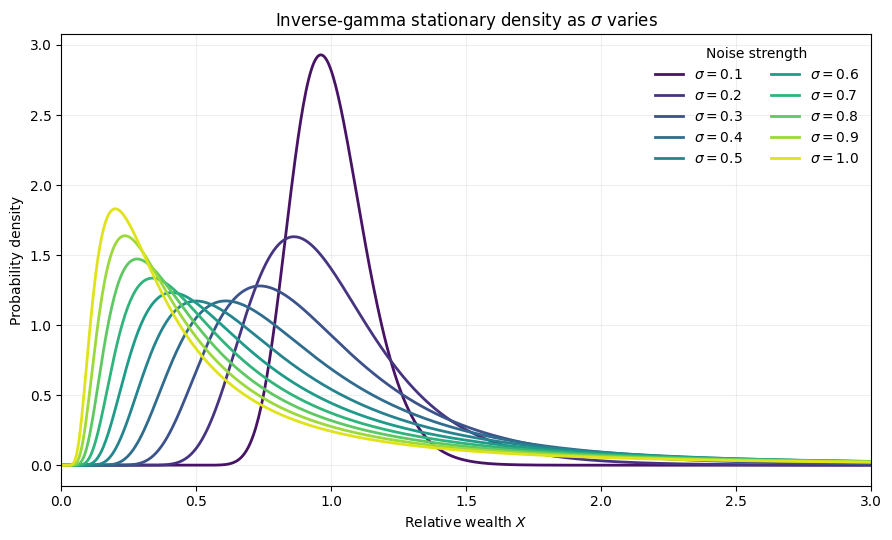

In [17]:
# Theoretical stationary densities as the noise strength varies.
sigma_values = np.linspace(0.1, 1.0, 10)
x_sweep = np.linspace(1e-3, 10.0, 2000)
colors = plt.colormaps["viridis"](np.linspace(0.05, 0.95, len(sigma_values)))

fig, ax = plt.subplots(figsize=(9, 5.5))
for color, sigma_value in zip(colors, sigma_values):
    alpha_value = 1 + J / sigma_value**2
    beta_value = J / sigma_value**2
    density = inverse_gamma_pdf(x_sweep, alpha_value, beta_value)
    ax.plot(x_sweep, density, color=color, linewidth=2, label=rf"$\sigma={sigma_value:.1f}$")

ax.set(
    xlim=(0, 10),
    xlabel="Relative wealth $X$",
    ylabel="Probability density",
    title=rf"Inverse-gamma stationary density as $\sigma$ varies",
)
ax.legend(title="Noise strength", ncol=2, frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.xlim(0, 3)
plt.show()
